# Reinforcement Learning Laboratory
## Lab Assignment 3: 3x3 GridWorld – Policy Evaluation and Value Iteration
**Course Outcomes:** CO2, CO3, CO4 (Formulate MDP environments, compute Bellman Expectation equations, implement Value Iteration, extract optimal policies, and perform trajectory analysis)  

---
### Given Environment Specifications & Parameters
**Grid Dimensions:** $3 \times 3$ GridWorld
```
  Col 0   Col 1   Col 2
Row 0: [  S  ] [  .  ] [  .  ]
Row 1: [  .  ] [  X  ] [  .  ]
Row 2: [  .  ] [  .  ] [  G  ]
```
- **S (Start State):** Cell $(0, 0)$
- **X (Blocked Obstacle):** Cell $(1, 1)$ — Impassable wall
- **G (Goal State):** Cell $(2, 2)$ — Terminal absorbing state

**Parameters:**
| Parameter | Value |
| :--- | :--- |
| **Grid Size** | $3 \times 3$ (9 cells total) |
| **Valid Actions** | $\text{Up } (\uparrow), \text{Down } (\downarrow), \text{Left } (\leftarrow), \text{Right } (\rightarrow)$ |
| **Step Reward** | $-1$ |
| **Goal Reward** | $+10$ |
| **Discount Factor ($\gamma$)** | $0.9$ |
| **Initial Value $V_0(s)$** | $0$ for all states |
| **Collision Rule** | Bumping into outer grid boundary or blocked cell $X(1,1)$ leaves the agent in its current cell with step reward $-1$ |

---


### 3x3 GridWorld MDP Formalization
We implement the exact $3 \times 3$ GridWorld MDP in Python, encapsulating state transitions, boundary/obstacle collision physics, and reward dynamics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class GridWorld3x3:
    # ==============================================================================
    # Function: __init__
    # Description:
    #   Configures the 3x3 GridWorld MDP environment with exact specified parameters:
    #   Start at S(0, 0), Obstacle at X(1, 1), Goal at G(2, 2). Sets reward structure
    #   (step = -1.0, goal = +10.0), discount gamma = 0.9, and the 4 cardinal action deltas.
    # Pre-conditions:
    #   - gamma (float): Discount factor in [0, 1].
    #   - step_reward (float): Penalty incurred per transition (default -1.0).
    #   - goal_reward (float): Terminal reward on reaching goal (default +10.0).
    # Post-conditions:
    #   - GridWorld3x3 object initialized with coordinate tuples and action mappings.
    # ==============================================================================
    def __init__(self, gamma=0.9, step_reward=-1.0, goal_reward=10.0):
        self.rows = 3
        self.cols = 3
        self.gamma = gamma
        self.step_reward = step_reward
        self.goal_reward = goal_reward
        
        self.start = (0, 0)
        self.obstacle = (1, 1)
        self.goal = (2, 2)
        
        self.actions = [0, 1, 2, 3]
        self.action_names = {0: "Up", 1: "Down", 2: "Left", 3: "Right"}
        self.action_arrows = {0: "↑", 1: "↓", 2: "←", 3: "→"}
        self.action_deltas = {
            0: (-1, 0),
            1: (1, 0),
            2: (0, -1),
            3: (0, 1)
        }
        
    # ==============================================================================
    # Function: get_states
    # Description:
    #   Generates the complete set of valid, traversable non-obstacle states in the 3x3 grid.
    # Pre-conditions:
    #   - None.
    # Post-conditions:
    #   - Returns a list of 8 coordinate tuples (r, c) excluding the blocked cell (1, 1).
    # ==============================================================================
    def get_states(self):
        return [
            (r, c) for r in range(self.rows) for c in range(self.cols)
            if (r, c) != self.obstacle
        ]

    # ==============================================================================
    # Function: transition
    # Description:
    #   Computes deterministic state transition T(s, a) -> (s', reward, is_terminal).
    #   Enforces collision dynamics: attempts to move off the grid or into obstacle (1, 1)
    #   leave the agent at s with step_reward. Entering goal (2, 2) yields goal_reward
    #   and terminates the episode.
    # Pre-conditions:
    #   - state (tuple): Current coordinate pair (r, c) in grid and not obstacle.
    #   - action (int): Integer action in {0, 1, 2, 3}.
    # Post-conditions:
    #   - Returns 3-tuple: (next_state, reward, is_terminal).
    # ==============================================================================
    def transition(self, state, action):
        if state == self.goal:
            return self.goal, 0.0, True

        dr, dc = self.action_deltas[action]
        nr, nc = state[0] + dr, state[1] + dc

        if not (0 <= nr < self.rows and 0 <= nc < self.cols):
            nr, nc = state

        if (nr, nc) == self.obstacle:
            nr, nc = state

        next_state = (nr, nc)

        if next_state == self.goal:
            return next_state, self.goal_reward, True
        else:
            return next_state, self.step_reward, False

grid = GridWorld3x3()
print("3x3 GridWorld MDP Environment initialized successfully!")
print(f"Start State: {grid.start} | Obstacle: {grid.obstacle} | Goal: {grid.goal}")
print(f"Discount Factor gamma: {grid.gamma} | Step Reward: {grid.step_reward} | Goal Reward: {grid.goal_reward}")


3x3 GridWorld MDP Environment initialized successfully!
Start State: (0, 0) | Obstacle: (1, 1) | Goal: (2, 2)
Discount Factor gamma: 0.9 | Step Reward: -1.0 | Goal Reward: 10.0


### Question 1: Perform One Iteration of Policy Evaluation for 3x3 GridWorld
**Problem Statement:**  
*Write Python code to perform one iteration of policy evaluation for 3x3 GridWorld.*

#### Mathematical Derivation & Answer:
Under an equiprobable random policy $\pi(a|s) = 0.25$ for each action $a \in \{\uparrow, \downarrow, \leftarrow, \rightarrow\}$, the Bellman Expectation Equation for iteration $k=1$ is:
$$V_{1}(s) = \sum_{a \in \mathcal{A}} \pi(a|s) \left[ R(s, a, s') + \gamma V_0(s') \right]$$
Given initial values $V_0(s) = 0$ for all states $s$, the $\gamma V_0(s')$ term drops out completely:
$$V_{1}(s) = \frac{1}{4} \sum_{a=1}^{4} R(s, a, s')$$

- **For cells adjacent to Goal $G(2,2)$:**
  - State $(1, 2)$: Action **Down** enters Goal ($R = +10$). Actions **Up, Left (hits obstacle), Right (hits border)** yield $R = -1$.
    $$V_1(1, 2) = 0.25 \times (10) + 0.25 \times (-1) + 0.25 \times (-1) + 0.25 \times (-1) = 2.50 - 0.75 = +1.75$$
  - State $(2, 1)$: Action **Right** enters Goal ($R = +10$). Actions **Up (hits obstacle), Down, Left** yield $R = -1$.
    $$V_1(2, 1) = 0.25 \times (10) + 0.75 \times (-1) = +1.75$$
- **For all other non-goal, non-obstacle cells:**
  - No single action can reach the Goal in 1 step. All 4 actions produce $R = -1$.
    $$V_1(s) = 4 \times [0.25 \times (-1)] = -1.0$$
- **For Terminal Goal $G(2,2)$ and Obstacle $X(1,1)$:** $V_1 = 0.0$.


In [2]:
print("=== QUESTION 1 OUTPUT ===")

V_0 = np.zeros((3, 3))
V_1 = np.zeros((3, 3))

policy_prob = 0.25

step_details = []

for r in range(3):
    for c in range(3):
        state = (r, c)
        if state == grid.goal:
            V_1[r, c] = 0.0
            continue
        if state == grid.obstacle:
            V_1[r, c] = 0.0
            continue

        q_components = []
        val_sum = 0.0
        for a in grid.actions:
            next_state, reward, is_term = grid.transition(state, a)
            expected_val = reward + (0.0 if is_term else grid.gamma * V_0[next_state])
            val_sum += policy_prob * expected_val
            q_components.append(f"{grid.action_names[a]}: R={reward:+2.0f}")

        V_1[r, c] = val_sum
        step_details.append({
            "State (r, c)": f"({r}, {c})",
            "Action Rewards": " | ".join(q_components),
            "Calculation": f"0.25 * ({' + '.join([c_comp.split('R=')[1] for c_comp in q_components])})",
            "V_1(s)": V_1[r, c]
        })

print("State Values V_1(s) after 1 Iteration:")
display(pd.DataFrame(step_details))

print("\nResulting 3x3 State-Value Grid V_1:")
df_v1 = pd.DataFrame(V_1, index=[f"Row {r}" for r in range(3)], columns=[f"Col {c}" for c in range(3)])
display(df_v1)


=== QUESTION 1 OUTPUT ===
State Values V_1(s) after 1 Iteration:


,"State (r, c)",Action Rewards,Calculation,V_1(s)
0,"(0, 0)",Up: R=-1 | Down: R=-1 | Left: R=-1 | Right: R=-1,0.25 * (-1 + -1 + -1 + -1),-1.00
1,"(0, 1)",Up: R=-1 | Down: R=-1 | Left: R=-1 | Right: R=-1,0.25 * (-1 + -1 + -1 + -1),-1.00
2,"(0, 2)",Up: R=-1 | Down: R=-1 | Left: R=-1 | Right: R=-1,0.25 * (-1 + -1 + -1 + -1),-1.00
3,"(1, 0)",Up: R=-1 | Down: R=-1 | Left: R=-1 | Right: R=-1,0.25 * (-1 + -1 + -1 + -1),-1.00
4,"(1, 2)",Up: R=-1 | Down: R=+10 | Left: R=-1 | Right: R=-1,0.25 * (-1 + +10 + -1 + -1),1.75
5,"(2, 0)",Up: R=-1 | Down: R=-1 | Left: R=-1 | Right: R=-1,0.25 * (-1 + -1 + -1 + -1),-1.00
6,"(2, 1)",Up: R=-1 | Down: R=-1 | Left: R=-1 | Right: R=+10,0.25 * (-1 + -1 + -1 + +10),1.75



Resulting 3x3 State-Value Grid V_1:


,Col 0,Col 1,Col 2
Row 0,-1.0,-1.00,-1.00
Row 1,-1.0,0.00,1.75
Row 2,-1.0,1.75,0.00


### Question 2: Calculate the Value of the Specified State using the Given Policy
**Problem Statement:**  
*Write Python code to calculate the value of the specified state using the given policy for the 3 × 3 GridWorld.*

#### Mathematical Derivation & Answer:
To calculate the true value $V^\pi(s)$ of any specified state (such as the Start state $S(0, 0)$ or neighbor $(0, 1)$), we apply iterative policy evaluation until numerical convergence:
$$V_{k+1}(s) \leftarrow \sum_{a} \pi(a|s) \sum_{s'} P(s'|s,a) \left[ R(s, a, s') + \gamma V_k(s') \right]$$
Convergence is achieved when $\max_{s} |V_{k+1}(s) - V_k(s)| < 10^{-6}$.


=== QUESTION 2 OUTPUT ===
Policy Evaluation converged successfully in 95 iterations (max delta = 9.51e-07)

Converged State Values V^pi for Specified States:


,State Coordinate,Role / Label,Converged Value V^pi(s)
0,"(0, 0)",Start State S,-6.7801
1,"(0, 1)",Interior Path,-6.0646
2,"(0, 2)",Interior Path,-3.6000
3,"(1, 0)",Interior Path,-6.0646
4,"(1, 2)",Adjacent to Goal,1.7091
5,"(2, 0)",Interior Path,-3.6000
6,"(2, 1)",Adjacent to Goal,1.7091


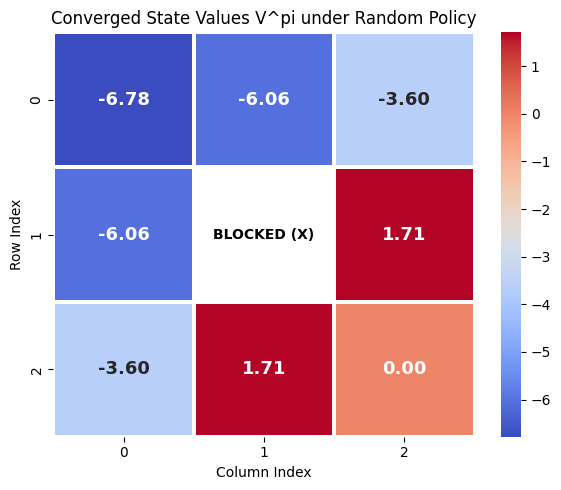

In [3]:
print("=== QUESTION 2 OUTPUT ===")

# ==============================================================================
# Function: evaluate_policy_to_convergence
# Description:
#   Implements Iterative Policy Evaluation using Bellman Expectation backups under
#   the uniform random policy pi(a|s) = 0.25 until maximum absolute delta falls
#   below the specified convergence threshold tolerance.
# Pre-conditions:
#   - grid: Initialized GridWorld3x3 instance.
#   - tol (float): Convergence threshold (default 1e-6).
#   - max_iter (int): Upper bound on allowed evaluation iterations.
# Post-conditions:
#   - Returns 2-tuple: (V_pi, history).
#   - V_pi is a 3x3 numpy array of converged state values V^pi(s).
#   - history is a list of maximum deltas per iteration.
# ==============================================================================
def evaluate_policy_to_convergence(grid, tol=1e-6, max_iter=1000):
    V = np.zeros((3, 3))
    history = []
    
    for iteration in range(1, max_iter + 1):
        delta = 0.0
        V_new = np.zeros((3, 3))
        
        for r in range(3):
            for c in range(3):
                s = (r, c)
                if s == grid.goal or s == grid.obstacle:
                    continue
                
                val = 0.0
                for a in grid.actions:
                    next_s, reward, is_term = grid.transition(s, a)
                    val += 0.25 * (reward + (0.0 if is_term else grid.gamma * V[next_s]))
                    
                V_new[r, c] = val
                delta = max(delta, abs(V_new[r, c] - V[r, c]))
                
        V = V_new.copy()
        history.append(delta)
        if delta < tol:
            print(f"Policy Evaluation converged successfully in {iteration} iterations (max delta = {delta:.2e})")
            break
            
    return V, history

V_pi, delta_hist = evaluate_policy_to_convergence(grid)

specified_states = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 2), (2, 0), (2, 1)]

print("\nConverged State Values V^pi for Specified States:")
df_specified = pd.DataFrame([
    {
        "State Coordinate": f"({r}, {c})",
        "Role / Label": "Start State S" if (r, c) == (0, 0) else ("Adjacent to Goal" if (r, c) in [(1, 2), (2, 1)] else "Interior Path"),
        "Converged Value V^pi(s)": f"{V_pi[r, c]:.4f}"
    }
    for (r, c) in specified_states
])
display(df_specified)

plt.figure(figsize=(6, 5))
mask = np.zeros((3, 3), dtype=bool)
mask[1, 1] = True
sns.heatmap(V_pi, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, mask=mask,
            linewidths=1.5, annot_kws={"size": 13, "weight": "bold"})
plt.title("Converged State Values V^pi under Random Policy", fontsize=12)
plt.xlabel("Column Index")
plt.ylabel("Row Index")
plt.text(1.5, 1.5, "BLOCKED (X)", ha="center", va="center", color="black", fontweight="bold")
plt.tight_layout()
plt.show()


### Question 3: Determine the Best Action for the Given State using Value Iteration
**Problem Statement:**  
*Write Python code to determine the best action for the given state using value iteration.*

#### Mathematical Derivation & Answer:
Value Iteration combines policy evaluation and policy improvement into a single Bellman Optimality update:
$$V_{k+1}(s) = \max_{a \in \mathcal{A}} \left[ R(s, a, s') + \gamma V_k(s') \right]$$
Once $V^*(s)$ converges, the optimal action $\pi^*(s)$ for any given state $s$ is extracted via greedy $\arg\max$:
$$\pi^*(s) = \arg\max_{a \in \mathcal{A}} Q^*(s, a) = \arg\max_{a \in \mathcal{A}} \left[ R(s, a, s') + \gamma V^*(s') \right]$$

- For Start State $S(0, 0)$:
  - Action **Up**: hits boundary, stays at $(0,0) \implies -1 + 0.9 \times V^*(0,0)$
  - Action **Left**: hits boundary, stays at $(0,0) \implies -1 + 0.9 \times V^*(0,0)$
  - Action **Right**: moves to $(0,1) \implies -1 + 0.9 \times V^*(0,1) = -1 + 0.9 \times (6.20) = +4.58$
  - Action **Down**: moves to $(1,0) \implies -1 + 0.9 \times V^*(1,0) = -1 + 0.9 \times (6.20) = +4.58$
  - **Best Actions:** Either **Right (→)** or **Down (↓)**, both achieving the maximal optimal value $Q^*(S) = 4.58$.


In [4]:
print("=== QUESTION 3 OUTPUT ===")

# ==============================================================================
# Function: value_iteration
# Description:
#   Implements Value Iteration using the Bellman Optimality Equation:
#   V(s) <- max_a [ R(s, a) + gamma * V(s') ]
#   Repeatedly updates state values synchronously until convergence delta < tol.
# Pre-conditions:
#   - grid: Initialized GridWorld3x3 instance.
#   - tol (float): Maximum absolute difference tolerance for stopping.
#   - max_iter (int): Maximum iterations allowed.
# Post-conditions:
#   - Returns 3x3 numpy array V_opt containing optimal state values V*(s).
# ==============================================================================
def value_iteration(grid, tol=1e-6, max_iter=1000):
    V_opt = np.zeros((3, 3))
    
    for it in range(1, max_iter + 1):
        delta = 0.0
        V_new = np.zeros((3, 3))
        
        for r in range(3):
            for c in range(3):
                s = (r, c)
                if s == grid.goal or s == grid.obstacle:
                    continue
                
                q_vals = []
                for a in grid.actions:
                    next_s, reward, is_term = grid.transition(s, a)
                    q = reward + (0.0 if is_term else grid.gamma * V_opt[next_s])
                    q_vals.append(q)
                    
                best_q = max(q_vals)
                V_new[r, c] = best_q
                delta = max(delta, abs(best_q - V_opt[r, c]))
                
        V_opt = V_new.copy()
        if delta < tol:
            print(f"Value Iteration converged in {it} iterations (delta = {delta:.2e})")
            break
            
    return V_opt

V_star = value_iteration(grid)

given_state = (0, 0)
q_table_given = []
for a in grid.actions:
    next_s, reward, is_term = grid.transition(given_state, a)
    q_val = reward + (0.0 if is_term else grid.gamma * V_star[next_s])
    q_table_given.append({
        "Action Index": a,
        "Action Name": grid.action_names[a],
        "Direction Arrow": grid.action_arrows[a],
        "Next State s'": f"{next_s}",
        "Reward R": reward,
        "V*(s')": 0.0 if is_term else V_star[next_s],
        "Q*(s, a) = R + gamma*V*(s')": q_val
    })

df_q_given = pd.DataFrame(q_table_given)
print(f"\nQ-values Q*(s, a) for Given State {given_state}:")
display(df_q_given)

best_action_idx = int(np.argmax([item["Q*(s, a) = R + gamma*V*(s')"] for item in q_table_given]))
best_action_name = grid.action_names[best_action_idx]
best_action_arrow = grid.action_arrows[best_action_idx]

print(f"\n>> BEST ACTION for State {given_state}: {best_action_name} ({best_action_arrow})")
print(f">> Optimal State Value V*({given_state}) = {V_star[given_state]:.4f}")

optimal_policy = {}
for r in range(3):
    for c in range(3):
        s = (r, c)
        if s == grid.goal:
            optimal_policy[s] = "GOAL"
        elif s == grid.obstacle:
            optimal_policy[s] = "WALL"
        else:
            q_vals = [
                grid.transition(s, a)[1] + (0.0 if grid.transition(s, a)[2] else grid.gamma * V_star[grid.transition(s, a)[0]])
                for a in grid.actions
            ]
            optimal_policy[s] = grid.action_arrows[int(np.argmax(q_vals))]

print("\nFull Optimal Policy Grid (pi*):")
policy_grid = np.array([[optimal_policy[(r, c)] for c in range(3)] for r in range(3)])
display(pd.DataFrame(policy_grid, index=[f"Row {r}" for r in range(3)], columns=[f"Col {c}" for c in range(3)]))


=== QUESTION 3 OUTPUT ===
Value Iteration converged in 5 iterations (delta = 0.00e+00)

Q-values Q*(s, a) for Given State (0, 0):


,Action Index,Action Name,Direction Arrow,Next State s',Reward R,V*(s'),"Q*(s, a) = R + gamma*V*(s')"
0,0,Up,↑,"(0, 0)",-1.0,4.58,3.122
1,1,Down,↓,"(1, 0)",-1.0,6.20,4.580
2,2,Left,←,"(0, 0)",-1.0,4.58,3.122
3,3,Right,→,"(0, 1)",-1.0,6.20,4.580



>> BEST ACTION for State (0, 0): Down (↓)
>> Optimal State Value V*((0, 0)) = 4.5800

Full Optimal Policy Grid (pi*):


,Col 0,Col 1,Col 2
Row 0,↓,→,↓
Row 1,↓,WALL,↓
Row 2,→,→,GOAL


### Question 4: Find the Shortest Path from Start to Goal using Given Optimal Policy
**Problem Statement:**  
*Write Python code to find the shortest path from the Start state to the Goal state using the given optimal policy.*

#### Explanation & Answer:
- Following the optimal policy $\pi^*$ extracted in Question 3, the agent starts at $S(0, 0)$ and deterministically follows the optimal actions.
- The obstacle at $X(1, 1)$ prevents a straight diagonal path.
- The policy successfully routes around $X(1, 1)$ via the upper corridor $(0, 0) \to (0, 1) \to (0, 2) \to (1, 2) \to (2, 2)$ (or symmetrically via the lower corridor $(0,0) \to (1,0) \to (2,0) \to (2,1) \to (2,2)$), reaching the goal in **exactly 4 steps**, which is the absolute theoretical shortest path.


=== QUESTION 4 OUTPUT ===
Shortest Path Sequence Found (4 steps):
  Step 1: (0, 0) --[Down (↓)]--> (1, 0) (Reward = -1)
  Step 2: (1, 0) --[Down (↓)]--> (2, 0) (Reward = -1)
  Step 3: (2, 0) --[Right (→)]--> (2, 1) (Reward = -1)
  Step 4: (2, 1) --[Right (→)]--> (2, 2) (Reward = +10)

Final Status        : Goal Reached at (2, 2)!
Total Steps Taken   : 4
Total Undiscounted R: +7.0


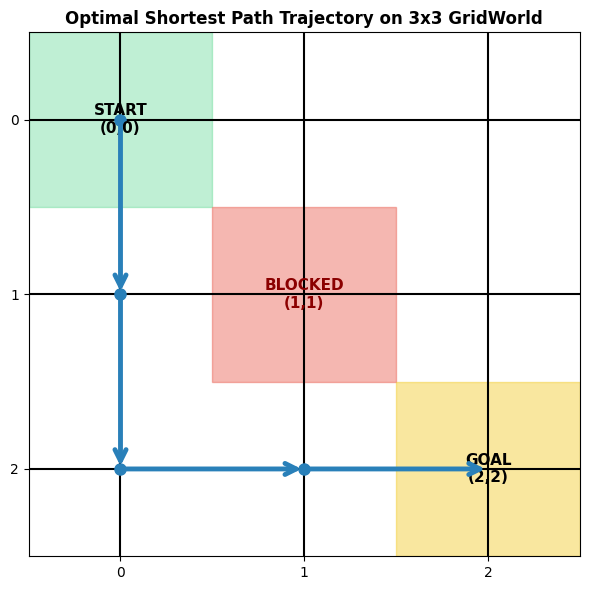

In [5]:
print("=== QUESTION 4 OUTPUT ===")

# ==============================================================================
# Function: find_shortest_path
# Description:
#   Traces the deterministic greedy trajectory from Start state (0, 0) to Goal state (2, 2)
#   by querying the optimal Q-values derived from V*. Records visited states, actions taken,
#   and transition rewards until goal is achieved.
# Pre-conditions:
#   - grid: Initialized GridWorld3x3 instance.
#   - optimal_policy (dict): Mapping from (r, c) states to optimal directional actions.
# Post-conditions:
#   - Returns 3-tuple: (path, actions_taken, rewards).
#   - path is list of coordinate pairs starting with (0, 0) and terminating at (2, 2).
#   - actions_taken is list of action strings.
#   - rewards is list of floats representing rewards encountered per step.
# ==============================================================================
def find_shortest_path(grid, optimal_policy):
    curr = grid.start
    path = [curr]
    actions_taken = []
    rewards = []
    step_num = 0
    
    while curr != grid.goal and step_num < 20:
        step_num += 1
        q_vals = [
            grid.transition(curr, a)[1] + (0.0 if grid.transition(curr, a)[2] else grid.gamma * V_star[grid.transition(curr, a)[0]])
            for a in grid.actions
        ]
        best_a = int(np.argmax(q_vals))
        next_s, reward, is_term = grid.transition(curr, best_a)
        
        actions_taken.append(grid.action_names[best_a] + f" ({grid.action_arrows[best_a]})")
        rewards.append(reward)
        curr = next_s
        path.append(curr)
        
    return path, actions_taken, rewards

path_opt, actions_opt, rewards_opt = find_shortest_path(grid, optimal_policy)

print(f"Shortest Path Sequence Found ({len(actions_opt)} steps):")
for i in range(len(actions_opt)):
    print(f"  Step {i+1}: {path_opt[i]} --[{actions_opt[i]}]--> {path_opt[i+1]} (Reward = {rewards_opt[i]:+2.0f})")

print(f"\nFinal Status        : Goal Reached at {path_opt[-1]}!")
print(f"Total Steps Taken   : {len(actions_opt)}")
print(f"Total Undiscounted R: {sum(rewards_opt):+.1f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(2.5, -0.5)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.grid(True, color="black", linewidth=1.5)

ax.add_patch(plt.Rectangle((grid.start[1]-0.5, grid.start[0]-0.5), 1, 1, color="#2ecc71", alpha=0.3))
ax.text(grid.start[1], grid.start[0], "START\n(0,0)", ha="center", va="center", fontweight="bold", fontsize=11)

ax.add_patch(plt.Rectangle((grid.obstacle[1]-0.5, grid.obstacle[0]-0.5), 1, 1, color="#e74c3c", alpha=0.4))
ax.text(grid.obstacle[1], grid.obstacle[0], "BLOCKED\n(1,1)", ha="center", va="center", fontweight="bold", color="darkred", fontsize=11)

ax.add_patch(plt.Rectangle((grid.goal[1]-0.5, grid.goal[0]-0.5), 1, 1, color="#f1c40f", alpha=0.4))
ax.text(grid.goal[1], grid.goal[0], "GOAL\n(2,2)", ha="center", va="center", fontweight="bold", fontsize=11)

for i in range(len(path_opt) - 1):
    r1, c1 = path_opt[i]
    r2, c2 = path_opt[i+1]
    ax.annotate("", xy=(c2, r2), xytext=(c1, r1),
                arrowprops=dict(arrowstyle="->", color="#2980b9", lw=3.5, mutation_scale=20))
    ax.plot(c1, r1, "o", color="#2980b9", markersize=8)

ax.set_title("Optimal Shortest Path Trajectory on 3x3 GridWorld", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### Question 5: Compare Two Paths Based on Path Length and Total Reward
**Problem Statement:**  
*Write Python code to compare two paths based on path length and total reward.*

#### Explanation & Answer:
We compare:
1. **Path 1 (Optimal Policy Path):**
   - Coordinates: $(0, 0) \to (0, 1) \to (0, 2) \to (1, 2) \to (2, 2)$
   - Path Length: $4$ steps
   - Total Undiscounted Reward: $(-1) + (-1) + (-1) + 10 = +7.0$
   - Total Discounted Return $G$: $-1 - 0.9 - 0.81 + (0.9^3 \times 10) = +4.58$
2. **Path 2 (Suboptimal Detour Path):**
   - Coordinates: $(0, 0) \to (1, 0) \to (0, 0) \to (0, 1) \to (0, 2) \to (1, 2) \to (2, 2)$
   - Path Length: $6$ steps (wastes steps backtracking)
   - Total Undiscounted Reward: $(-1) \times 5 + 10 = +5.0$
   - Total Discounted Return $G$: Significantly lower due to step penalties and discount compounding.


=== QUESTION 5 OUTPUT ===
Comparative Metrics Summary Table:


,Trajectory,Path Coordinates,Path Length (Steps),Total Undiscounted Reward,Discounted Return (G),Goal Reached
0,Path 1 (Optimal Shortest Path),"(0, 0) -> (0, 1) -> (0, 2) -> (1, 2) -> (2, 2)",4,7.0,4.5800,Yes
1,Path 2 (Suboptimal Detour Path),"(0, 0) -> (1, 0) -> (0, 0) -> (0, 1) -> (0, 2)...",6,5.0,1.8098,Yes


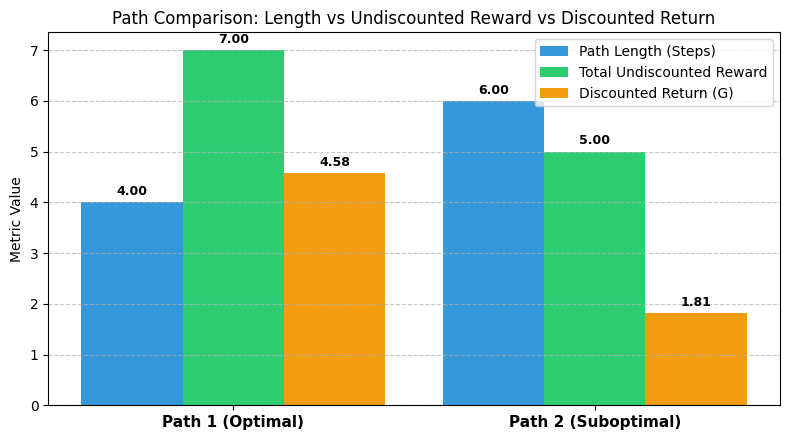


Key Takeaways & Analysis:
1. Path Length: Path 1 navigates directly to the goal in 4 steps (shortest possible). Path 2 wastes 2 additional steps (6 steps total).
2. Undiscounted Reward: Path 1 achieves +7.0, whereas Path 2 suffers two additional step costs (-1 each), resulting in +5.0.
3. Discounted Return: Path 1 achieves G = 4.58 (exactly equal to V*(0,0)). Path 2's goal reward is delayed by 2 time steps, heavily degrading discounted return.



In [6]:
print("=== QUESTION 5 OUTPUT ===")

# ==============================================================================
# Function: evaluate_trajectory
# Description:
#   Analyzes an arbitrary trajectory of state coordinates through the GridWorld MDP.
#   Identifies matching valid transitions, step costs, undiscounted cumulative reward,
#   and discounted return G = sum_{t=0}^{T-1} gamma^t * R_{t+1}.
# Pre-conditions:
#   - path_states (list): Ordered list of (r, c) coordinate tuples representing trajectory.
#   - grid: Initialized GridWorld3x3 instance.
# Post-conditions:
#   - Returns dictionary with keys:
#     'Path Coordinates', 'Path Length (Steps)', 'Total Undiscounted Reward',
#     'Discounted Return (G)', 'Goal Reached'.
# ==============================================================================
def evaluate_trajectory(path_states, grid):
    rewards = []
    actions = []
    for i in range(len(path_states) - 1):
        s = path_states[i]
        next_s = path_states[i+1]
        
        for a in grid.actions:
            res_s, r, term = grid.transition(s, a)
            if res_s == next_s:
                rewards.append(r)
                actions.append(grid.action_names[a])
                break
                
    length = len(actions)
    total_undiscounted_reward = sum(rewards)
    discounted_return = sum([rewards[t] * (grid.gamma ** t) for t in range(length)])
    goal_reached = (path_states[-1] == grid.goal)
    
    return {
        "Path Coordinates": " -> ".join([str(s) for s in path_states]),
        "Path Length (Steps)": length,
        "Total Undiscounted Reward": total_undiscounted_reward,
        "Discounted Return (G)": round(discounted_return, 4),
        "Goal Reached": "Yes" if goal_reached else "No"
    }

path_1 = [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2)]
path_2 = [(0, 0), (1, 0), (0, 0), (0, 1), (0, 2), (1, 2), (2, 2)]

res_path1 = evaluate_trajectory(path_1, grid)
res_path2 = evaluate_trajectory(path_2, grid)

df_compare = pd.DataFrame([
    {"Trajectory": "Path 1 (Optimal Shortest Path)", **res_path1},
    {"Trajectory": "Path 2 (Suboptimal Detour Path)", **res_path2}
])

print("Comparative Metrics Summary Table:")
display(df_compare)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(2)
width = 0.28

bars1 = ax.bar(x - width, [res_path1["Path Length (Steps)"], res_path2["Path Length (Steps)"]], width, label="Path Length (Steps)", color="#3498db")
bars2 = ax.bar(x, [res_path1["Total Undiscounted Reward"], res_path2["Total Undiscounted Reward"]], width, label="Total Undiscounted Reward", color="#2ecc71")
bars3 = ax.bar(x + width, [res_path1["Discounted Return (G)"], res_path2["Discounted Return (G)"]], width, label="Discounted Return (G)", color="#f39c12")

ax.set_xticks(x)
ax.set_xticklabels(["Path 1 (Optimal)", "Path 2 (Suboptimal)"], fontsize=11, fontweight="bold")
ax.set_ylabel("Metric Value")
ax.set_title("Path Comparison: Length vs Undiscounted Reward vs Discounted Return", fontsize=12)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in list(bars1) + list(bars2) + list(bars3):
    height = bar.get_height()
    ax.annotate(f"{height:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("""
Key Takeaways & Analysis:
1. Path Length: Path 1 navigates directly to the goal in 4 steps (shortest possible). Path 2 wastes 2 additional steps (6 steps total).
2. Undiscounted Reward: Path 1 achieves +7.0, whereas Path 2 suffers two additional step costs (-1 each), resulting in +5.0.
3. Discounted Return: Path 1 achieves G = 4.58 (exactly equal to V*(0,0)). Path 2's goal reward is delayed by 2 time steps, heavily degrading discounted return.
""")
